# Figure 2

Known pressure and measured dissolved H2O concentration in pure-H2O solubility experiment samples (dots) using basalt (blue), andesite (orange), and rhyolite (red) magmas. The corresponding curves are not fits to the data; they are pure-H2O solubility surfaces for average compositions from each dataset modeled with MagmaSat in VESIcal, illustrating the role of laboratory experiments, which are the foundation used to build petrologic models.

Citations for the published experimental data used in these plots is given in the accompanying xlsx files.

## About this notebook

This notebook uses numpy for creating a pressure array, VESIcal for computing solubility curves at those pressures, matplotlib for plotting, and pandas for working with tabular datasets.

The data calculated here is also given in accompanying csv files that can be read into this notebook and plotted without needing to compute them. Files used in this notebook:
- **Pure-H2O experimental samples:** 
    - Pure-H2O basalts: */data/experiments/experimental_basaltsH2O.xlsx*
    - Pure-H2O andesites: */data/experiments/experimental_andesitesH2O.xlsx*
    - Pure-H2O rhyolites: */data/experiments/experimental_rhyolitesH2O.xlsx*

- **CO2-bearing experimental basalts:** 
    - Mixed volatile CO2-bearing basalts: */data/experiments/experimental_basaltsCO2.xlsx*
    - with calculated Pi Parameter, optical basicity, NBO/T, and XCO2: */data/experiments/experimental_basaltsCO2_extra_calculations.xlsx*

In [1]:
# computation and data handling
import VESIcal as v
import pandas as pd
import numpy as np

# plotting and curve fitting
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from scipy.interpolate import interp1d

# custom calculations
import NBOT as nbo
import calc_pi as cpi
import Opt_Bas as ob

# silence pesky warnings
import warnings as w
w.simplefilter(action='ignore', category=FutureWarning)

# Figure 2a. H2O Solubility
## Import experimental samples
First, import our experimental data files using VESIcal, then save them as Pandas dataframes. 

In [2]:
########## IMPORT PURE H2O EXPERIMENT FILES ###########
H2O_basalt_exps = v.BatchFile("data/experiments/experimental_basaltsH2O.xlsx")
H2O_andesite_exps = v.BatchFile("data/experiments/experimental_andesitesH2O.xlsx")
H2O_rhyolite_exps = v.BatchFile("data/experiments/experimental_rhyolitesH2O.xlsx")

## Calculate XH2Omelt for experimental samples
Here, we will define a method to calculate the concentration of H2O in the melt in terms of mole fraction, perform the calculation, and save the calculated file.

In [3]:
def calculate_XH2O(bf):
    XH2O = 100*bf.get_data(units='mol_oxides')['H2O']
    df = bf.get_data()
    df["XH2O_melt"] = XH2O
    return df

# perform the calculation
[H2O_basalt_exps_df, H2O_andesite_exps_df, H2O_rhyolite_exps_df] = [
    calculate_XH2O(bf) for bf in [H2O_basalt_exps, 
                                  H2O_andesite_exps, 
                                  H2O_rhyolite_exps]
    ]

# save to files
H2O_basalt_exps_df.to_excel("data/computed/H2O_basalt_exps_df.xlsx")
H2O_andesite_exps_df.to_excel("data/computed/H2O_andesite_exps_df.xlsx")
H2O_rhyolite_exps_df.to_excel("data/computed/H2O_rhyolite_exps_df.xlsx")

## Average samples for modeling
Here we define a composition for an average basalt, andesite, and rhyolite. These averages are the average compositions of each experimental dataset.

In [4]:
########## H2O BASALT ###########
avg_H2O_basalt = v.Sample({
    "SiO2": 49.58,
    "TiO2": 1.36,
    "Al2O3": 15.51,
    "FeO": 10.05,
    "MnO": 0.16,
    "MgO": 7.14,
    "CaO": 11.89,
    "Na2O": 2.52,
    "K2O": 0.65,
    "P2O5": 0.22,
    })

########## H2O ANDESITE ###########
avg_H2O_andesite = v.Sample({
    "SiO2":     61.20,
    "TiO2":     0.80,
    "Al2O3":    17.62,
    "FeO":      4.74,
    "MnO":      0.07,
    "MgO":      2.90,
    "CaO":      5.99,
    "Na2O":     4.15,
    "K2O":      1.35,
    "P2O5":     0.25,
    })

########## H2O RHYOLITE ###########
avg_H2O_rhyolite = v.Sample({
    "SiO2": 74.24,
    "TiO2": 0.11,
    "Al2O3":13.20,
    "FeO":  1.73,
    "MnO":  0.07,
    "MgO":  0.02,
    "CaO":  0.33,
    "Na2O": 5.74,
    "K2O":  3.73,
    "P2O5": 0.01,
    })



## Model pure-H2O compositions
Next, we calculate the pure-H2O solubility for each average pure-H2O composition over our pressure range using MagmaSat in VESIcal. First, let's define a method for calculating the H2O solubility surface for n numer of samples.

In [21]:
def calculate_volatile_solubility_surface(samples: list,
                                          volatile: str,
                                          temperatures: list,
                                          pressure_range: np.array):
    """Calculates the pure H2O solubilty for individual samples passed as a list
    of VESIcal sample objects.

    Args:
        samples (list): list of VESIcal sample objects containing compositions 
        volatile (srt): can be one of "H2O" or "CO2"
        temperatures (list): list of temperatures (one for each sample)
        pressure_range (np.array): array of pressures. Ex: np.arange(1,7001,500)
    
    Returns:
        tuple: n-length tuple for n samples passed. Each item in the tuple is
        a Pandas dataframe with columns "Pressure" and "H2O"
    """
    # n_samples = len(samples)
    # # for sample in samples:
    # #     sample_dict = sample.get_composition()
    # #     print(sample.get_composition())
    # # bfs = [v.BatchFile(sample) for sample in samples]
    # # print(bfs[0].get_data())
    # dfs = [pd.DataFrame(columns=["Pressure", volatile]) for _ in range(n_samples)]
    
    if volatile == "H2O":
        X_fluid = 1
        vol_column = "H2O_liq"
    elif volatile == "CO2":
        X_fluid = 0
        vol_column = "CO2_liq"
    else:
        raise ValueError('volatile argument must be either \"H2O\" or \"CO2\"')
    
    dfs = []
    for i, sample in enumerate(samples):
        samples_with_data_list = []
        for press in pressure_range:
            diss_vols = v.calculate_dissolved_volatiles(
                sample=sample,
                temperature=temperatures[i],
                pressure=press,
                X_fluid=X_fluid,
                ).result
            # save all sample info to a dictionary
            comp_dict = sample.get_composition()
            comp_dict['T_C'] = temperatures[i]
            comp_dict['P_bar'] = press
            comp_dict['XH2O_fluid'] = X_fluid
            comp_dict[volatile] = diss_vols[vol_column]
            samples_with_data_list.append(comp_dict)
        computed_df = pd.DataFrame(samples_with_data_list)
        dfs.append(computed_df)
    
    dfs = [calculate_XH2O(v.BatchFile_from_DataFrame(df)) for df in dfs]
    
    return tuple(dfs)

### Next, calculate model curves using our method above
As with the extra calculations performed on the CO2-bearing experimental data above, here the user can choose to either: 1. import a file with already computed solubilities (faster); or 2. rerun the computations. This is made optional so that this code can be run without VESIcal or thermoengine installed and to speed up execution of the notebook. Set `use_computed_H2O` to False to recompute the solubility values. Even if set to True, the solubilities will be calculated if the existing pre-computed file cannot be found.

In [22]:
use_computed_H2O = False
if use_computed_H2O is True:
    try:
        model_H2O_basalt = pd.read_excel("data/computed/model_H2O_basalt.xlsx")
        model_H2O_andesite = pd.read_excel("data/computed/model_H2O_andesite.xlsx")
        model_H2O_rhyolite = pd.read_excel("data/computed/model_H2O_rhyolite.xlsx")
    except Exception as e:
        print(e, " Computing new solubilities.")
        model_H2O_basalt, model_H2O_andesite, model_H2O_rhyolite = calculate_volatile_solubility_surface(
            samples=[avg_H2O_basalt, avg_H2O_andesite, avg_H2O_rhyolite],
            temperatures=[1200, 1100, 980],
            pressure_range=np.arange(10,7001,500),
            volatile="H2O"
            )
        model_H2O_basalt.to_excel("data/computed/model_H2O_basalt.xlsx")
        model_H2O_andesite.to_excel("data/computed/model_H2O_andesite.xlsx")
        model_H2O_rhyolite.to_excel("data/computed/model_H2O_rhyolite.xlsx")
        
else:
    print("Computing new solubilities.")
    model_H2O_basalt, model_H2O_andesite, model_H2O_rhyolite = calculate_volatile_solubility_surface(
            samples=[avg_H2O_basalt, avg_H2O_andesite, avg_H2O_rhyolite],
            temperatures=[1200, 1100, 980],
            pressure_range=np.arange(10,7001,500),
            volatile="H2O"
            )
    model_H2O_basalt.to_excel("data/computed/model_H2O_basalt.xlsx")
    model_H2O_andesite.to_excel("data/computed/model_H2O_andesite.xlsx")
    model_H2O_rhyolite.to_excel("data/computed/model_H2O_rhyolite.xlsx")

Computing new solubilities.


## Plot the results
Finally, we plot pressure vs H2O concentration in wt% and pressure vs CO2 in wt%f or the experimental samples (in dots) and our modeled solubility surfaces (curves).

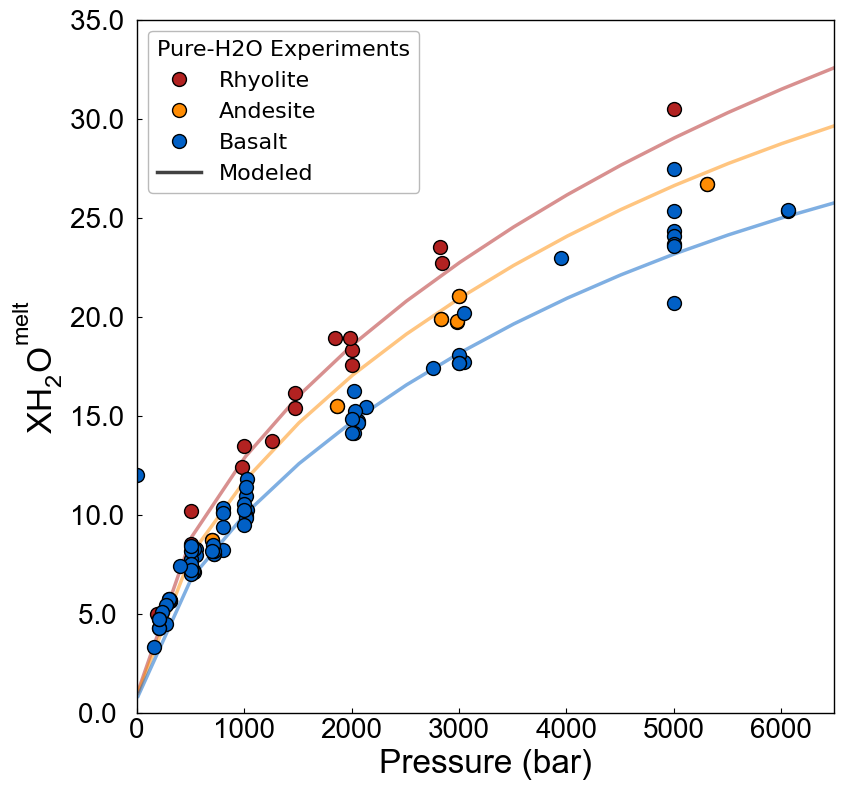

In [34]:
colors = [
    '#B22221',
    '#FF8C03',
    '#0160C6',
    
]

labels = [
    "Rhyolite",
    "Andesite",
    "Basalt",
]

fig, ax = plt.subplots(figsize=(9,9), dpi=100)
########## POINTS ###########
for i, df in enumerate(
    [H2O_rhyolite_exps_df, H2O_andesite_exps_df, H2O_basalt_exps_df]
    ):
    ax.plot(
    df["P_bar"],
    df["XH2O_melt"],
    'o',
    markersize=10,
    mec='k',
    mfc=colors[i],
    label=labels[i],
    zorder=2,
)

########## CURVES ###########
for i, dataset in enumerate(
    [model_H2O_rhyolite, model_H2O_andesite, model_H2O_basalt]
    ):
    line_label = "Modeled" if i == 1 else None
    ax.plot(
    dataset["P_bar"],
    dataset["XH2O_melt"],
    c=colors[i],
    alpha=0.5,
    linewidth=2.5,
    label=line_label,
    zorder=1,
)

########## PLOT STYLING ###########
ax.set_xlim(0,6500)
ax.set_ylim(0,35)

legend = ax.legend(fontsize=16)
legend.legend_handles[3].set_color("#424242")
legend.legend_handles[3].set_alpha(1)
legend.set_title("Pure-H2O Experiments", prop={'size': 16})
legend.set_alignment('left')
legend.get_frame().set_edgecolor('darkgray')


ax.set_xlabel(r'Pressure (bar)', fontsize=24, family='Arial')
ax.set_ylabel(r'XH$_2O^{melt}$', fontsize=24, family='Arial')

ax.tick_params(axis='x', labelsize=20, direction='in')
ax.tick_params(axis='y', labelsize=20, direction='in')

plt.xticks(fontname='Arial')
plt.yticks(fontname='Arial')

ax.yaxis.set_major_formatter('{x:<5.1f}')

fig.savefig('Figure2a.png', dpi=600, bbox_inches="tight")   # save the figure to file

plt.show()

### Optionally, save the computed solubility curves

In [ ]:
diss_H2O_basalt.to_csv("data/computed/diss_H2O_basalt.csv")
diss_H2O_andesite.to_csv("data/computed/diss_H2O_andesite.csv")
diss_H2O_rhyolite.to_csv("data/computed/diss_H2O_rhyolite.csv")

## Figure 2b. CO2 Solubility
### Import experimental data and define an average composition

In [ ]:
CO2_basalt_exps = v.BatchFile("data/experiments/experimental_basaltsCO2.xlsx")

########## AVERAGE BASALT FOR CO2 SOLUBILITY ###########
avg_CO2_basalt = v.Sample({
    "SiO2": 49.46,
    "TiO2": 1.76,
    "Al2O3": 15.28,
    "FeO": 10.88,
    "MnO": 0.16,
    "MgO": 7.81,
    "CaO": 11.29,
    "Na2O": 2.76,
    "K2O": 0.35,
    "P2O5": 0.19,
    })


### Calculate extra compositional parameters
For the CO2 data, we have pre-calculated the value of the Dixon et al. Pi Parameter, the optical basicity, and the NBO/T of each experimental sample. We have also binned samples into pressure groups for further computation and plotting. For completeness, these calculations are in the following cell. Set `use_computed` to False, and these calculations will be run on the dataset "CO2_basalts.xlsx". Set `use_computed` to True to simply import the already computed file.

In [ ]:
use_computed = True # set to False to re-run the computations

# DEFINE EXTRA CALCULATIONS
def extra_calculations_basaltsCO2():
    CO2_basalt_exps = v.BatchFile("data/experiments/CO2_basalts.xlsx")
    CO2_basalt_exps = nbo.batch_calc_NBO_T(CO2_basalt_exps)
    CO2_basalt_exps = cpi.batch_calc_Pi_parameter(CO2_basalt_exps)
    CO2_basalt_exps = ob.batch_calc_optical_basicity(CO2_basalt_exps)
    XCO2 = 100*CO2_basalt_exps.get_composition(units="mol_oxides")['CO2']
    CO2_basalt_df = CO2_basalt_exps.get_data()
    CO2_basalt_df["XCO2"] = XCO2

    # Compute nearest multiple of 500
    nearest = (CO2_basalt_df["P_bar"] / 1000).round() * 1000

    # Ensure the minimum snap is 500 (no zeros allowed)
    nearest = np.where(nearest < 1000, 1000, nearest)

    # Snap only if within ±10% of the candidate snap target
    CO2_basalt_df["P_bar_binned"] = np.where(
        (abs(CO2_basalt_df["P_bar"] - nearest) <= 0.1 * nearest),
        nearest,
        np.nan  # or np.nan if you prefer to drop unsnappable values
    ).astype(int)

    # remove outliers
    CO2_basalt_df = CO2_basalt_df[CO2_basalt_df["P_bar_binned"] > 500]
    CO2_basalt_df = CO2_basalt_df[CO2_basalt_df["P_bar_binned"] < 10000]

    CO2_basalt_df.to_excel("data/experiments/experimental_basaltsCO2_extra_calculations.xlsx")
    
    return CO2_basalt_df

if use_computed is True:
    try:
        CO2_basalt_df = pd.read_excel("data/experiments/experimental_basaltsCO2_extra_calculations.xlsx")
    
    except Exception as e:
        print(e, " Computing new solubilities.")
        extra_calculations_basaltsCO2()
        
else:
    extra_calculations_basaltsCO2()

### Create a set of generated data with range of alkali contents
Here we generate a dataset of our own samples using the average composition of the basalts in our mixed-fluid experiments database. To illustrate the effect of alkali content on CO2 solubility, our generated samples will range in total alkali contents from 0 to 10 wt% and with Na2O/K2O ratios from 0 to 10. Like above, set `use_computed` to False to recreate our model dataset. Otherwise, pre-computed values will be imported.

In [ ]:
use_computed = True # set to False to re-run the computations

# DEFINE SAMPLE COMPOSITION GENERATION
def generate_samples():
    samples_varied_alkalis_list = []
    for press in [2000, 4000, 6000]:
        for na2o in [0, 2, 4, 6, 8, 10]:
            for tot_alk in [0, 2, 4, 6, 8, 10]:
                k2o = tot_alk - na2o
                if k2o >= 0:
                    samp = avg_CO2_basalt.change_composition({"Na2O": na2o,
                                                                "K2O":k2o,
                                                                "P_bar": press})
                    samp = samp.get_composition()
                    samples_varied_alkalis_list.append(samp)
    samples_varied_alkalis_df = pd.concat(samples_varied_alkalis_list, axis=1).T

    samples_varied_alkalis_df["Total Alkalis"] = samples_varied_alkalis_df["Na2O"] + samples_varied_alkalis_df["K2O"]
    generated_data = v.BatchFile_from_DataFrame(samples_varied_alkalis_df)
    bf = generated_data.get_data(normalization="standard", asBatchFile=True)

    bf.save_excel("data/computed/generated_basalts.xlsx", None)
    
    return bf

if use_computed is True:
    try:
        generated_samples_bf = v.BatchFile("data/computed/generated_basalts.xlsx")
    except Exception as e:
        print(e, "\n Generating new samples.")
        generated_samples_bf = generate_samples()
else:
    generated_samples_bf = generate_samples()
        

### Calculate mixed-fluid solubilities for generated dataset
Like above, set `use_computed` to False to rerun solubility calculations. Otherwise, pre-computed values will be imported.

In [ ]:
use_computed = False

if use_computed is True:
    try:
        CO2_basalt_df = pd.read_excel("data/computed/generated_data_with_volatiles.xlsx")
    
    except Exception as e:
        print(e, " Computing new solubilities.")
        bf = v.BatchFile("data/computed/generated_basalts.xlsx")
        df = bf.calculate_dissolved_volatiles(pressure="P_bar", temperature=1200, X_fluid=0.5)
        df.rename(columns={'CO2_liq_VESIcal': 'CO2', 'H2O_liq_VESIcal': 'H2O'}, inplace=True)
        bf = v.BatchFile_from_DataFrame(df)
        XCO2 = 100*bf.get_composition(units="mol_oxides")['CO2']
        df = bf.get_data()
        df["XCO2"] = XCO2
        df.to_excel("data/computed/generated_data_with_volatiles.xlsx")
        
else:
    bf = v.BatchFile("data/computed/generated_basalts.xlsx")
    df = bf.calculate_dissolved_volatiles(pressure="P_bar", temperature=1200, X_fluid=0.5)
    df.rename(columns={'CO2_liq_VESIcal': 'CO2', 'H2O_liq_VESIcal': 'H2O'}, inplace=True)
    bf = v.BatchFile_from_DataFrame(df)
    XCO2 = 100*bf.get_composition(units="mol_oxides")['CO2']
    df = bf.get_data()
    df["XCO2"] = XCO2
    df.to_excel("data/computed/generated_data_with_volatiles.xlsx")


In [ ]:
colors_for_figure2b = ['#800080',
                       '#21B1B2',
                       '#dc267f']

import pandas as pd
# Import experimental data and generated average basalt data
exp_data = pd.read_excel("data/experiments/experimental_basaltsCO2_extra_calculations.xlsx")
avg_data = pd.read_excel("data/computed/generated_data_with_volatiles.xlsx")

fig, ax = plt.subplots(figsize=(9,9), dpi=100)

## EXPERIMENTAL DATA (scatter points)
for i, press in enumerate([2000, 4000, 6000]):
    filtered_df = exp_data[exp_data["P_bar_binned"] == press]
    ax.scatter(
        filtered_df["Total Alkalis"],
        filtered_df["XCO2"],
        s=100,  # marker size
        edgecolor="k",
        color=colors_for_figure2b[i],
        marker='D',
        label=f"{press} bar",
        zorder=2,
    )

## CURVES (smoothed splines)
for i, press in enumerate(avg_data["P_bar"].unique()):
    line_label = "Modeled" if press == min(avg_data["P_bar"].unique()) else None
    avg_filtered_df = avg_data[avg_data["P_bar"] == press].copy()
    
    # Group by Total Alkalis and take the mean of XCO2 values
    # This handles the multiple y-values for same x-values issue
    grouped_data = avg_filtered_df.groupby("Total Alkalis")["XCO2"].mean().reset_index()
    
    x = grouped_data["Total Alkalis"].values
    y = grouped_data["XCO2"].values
    
    # Sort before interpolation (should already be sorted, but just in case)
    order = np.argsort(x)
    x, y = x[order], y[order]
    
    # Create smooth x values for interpolation
    x_smooth = np.linspace(0, 10, 500)
    
    # Choose interpolation method based on number of points
    if len(x) >= 4:  # Need at least 4 points for cubic spline
        spline = make_interp_spline(x, y, k=3)  # cubic spline
        y_spline = spline(x_smooth)
        
        # Only plot values within the data range to avoid extrapolation artifacts
        valid_range = (x_smooth >= x.min()) & (x_smooth <= x.max())
        ax.plot(
            x_smooth[valid_range],
            y_spline[valid_range],
            lw=2.5,
            label=line_label,
            color = colors_for_figure2b[i],
            zorder=1,
            alpha=0.5
        )
            
    else:
        # Use linear interpolation for few points
        interp_func = interp1d(x, y, kind='linear')
        valid_range = (x_smooth >= x.min()) & (x_smooth <= x.max())
        y_interp = interp_func(x_smooth[valid_range])
        ax.plot(
            x_smooth[valid_range],
            y_interp,
            lw=2,
            label=f"{press} bar (linear)"
        )
        print(f"  -> Used linear interpolation (insufficient points for spline)")

########## PLOT STYLING ###########
ax.set_xlim(0, 10)
ax.set_ylim(0,)

legend = ax.legend(fontsize=16)
legend.legend_handles[3].set_color('k')
legend.set_title("Mixed-fluid Basalt Experiments", prop={'size': 16})
legend.set_alignment('left')
legend.get_frame().set_edgecolor('darkgray')

ax.set_xlabel(r'Total Alkalis (wt%)', fontsize=24, family='Arial')
ax.set_ylabel(r'XCO$_2^{melt}$', fontsize=24, family='Arial')
ax.tick_params(axis='x', labelsize=20, direction='in')
ax.tick_params(axis='y', labelsize=20, direction='in')
plt.xticks(fontname='Arial')
plt.yticks(fontname='Arial')
ax.yaxis.set_major_formatter('{x:<5.1f}')
ax.xaxis.set_major_formatter('{x:<5.1f}')

fig.savefig('Figure2b.png', dpi=600, bbox_inches="tight")
plt.show()

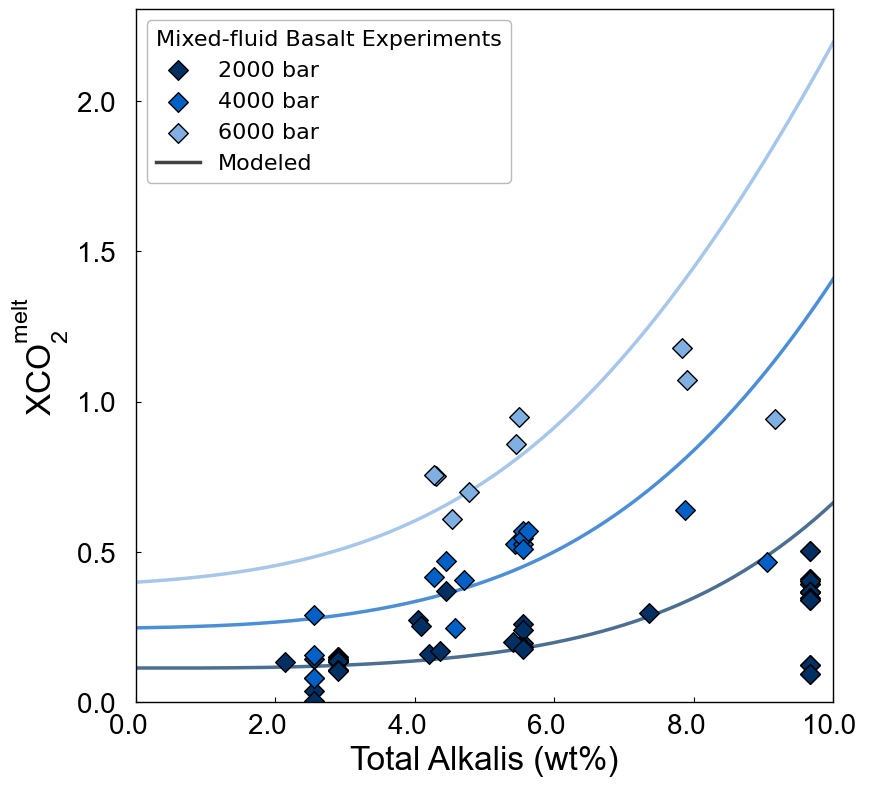

In [33]:
colors_for_figure2b = ['#003063',
                       '#0160c6',
                       '#80afe2']

import pandas as pd
# Import experimental data and generated average basalt data
exp_data = pd.read_excel("data/experiments/experimental_basaltsCO2_extra_calculations.xlsx")
avg_data = pd.read_excel("data/computed/generated_data_with_volatiles.xlsx")

fig, ax = plt.subplots(figsize=(9,9), dpi=100)

## EXPERIMENTAL DATA (scatter points)
for i, press in enumerate([2000, 4000, 6000]):
    filtered_df = exp_data[exp_data["P_bar_binned"] == press]
    ax.scatter(
        filtered_df["Total Alkalis"],
        filtered_df["XCO2"],
        s=100,  # marker size
        edgecolor="k",
        color=colors_for_figure2b[i],
        marker='D',
        label=f"{press} bar",
        zorder=2,
    )

## CURVES (smoothed splines)
for i, press in enumerate(avg_data["P_bar"].unique()):
    line_label = "Modeled" if press == min(avg_data["P_bar"].unique()) else None
    avg_filtered_df = avg_data[avg_data["P_bar"] == press].copy()
    
    # Group by Total Alkalis and take the mean of XCO2 values
    # This handles the multiple y-values for same x-values issue
    grouped_data = avg_filtered_df.groupby("Total Alkalis")["XCO2"].mean().reset_index()
    
    x = grouped_data["Total Alkalis"].values
    y = grouped_data["XCO2"].values
    
    # Sort before interpolation (should already be sorted, but just in case)
    order = np.argsort(x)
    x, y = x[order], y[order]
    
    # Create smooth x values for interpolation
    x_smooth = np.linspace(0, 10, 500)
    
    # Choose interpolation method based on number of points
    if len(x) >= 4:  # Need at least 4 points for cubic spline
        spline = make_interp_spline(x, y, k=3)  # cubic spline
        y_spline = spline(x_smooth)
        
        # Only plot values within the data range to avoid extrapolation artifacts
        valid_range = (x_smooth >= x.min()) & (x_smooth <= x.max())
        ax.plot(
            x_smooth[valid_range],
            y_spline[valid_range],
            lw=2.5,
            linestyle='-',
            label=line_label,
            color = colors_for_figure2b[i],
            zorder=1,
            alpha=0.7
        )
            
    else:
        # Use linear interpolation for few points
        interp_func = interp1d(x, y, kind='linear')
        valid_range = (x_smooth >= x.min()) & (x_smooth <= x.max())
        y_interp = interp_func(x_smooth[valid_range])
        ax.plot(
            x_smooth[valid_range],
            y_interp,
            lw=2,
            label=f"{press} bar (linear)"
        )
        print(f"  -> Used linear interpolation (insufficient points for spline)")

########## PLOT STYLING ###########
ax.set_xlim(0, 10)
ax.set_ylim(0,)

legend = ax.legend(fontsize=16)
legend.legend_handles[3].set_color("#424242")
legend.legend_handles[3].set_alpha(1)
legend.set_title("Mixed-fluid Basalt Experiments", prop={'size': 16})
legend.set_alignment('left')
legend.get_frame().set_edgecolor('darkgray')

ax.set_xlabel(r'Total Alkalis (wt%)', fontsize=24, family='Arial')
ax.set_ylabel(r'XCO$_2^{melt}$', fontsize=24, family='Arial')
ax.tick_params(axis='x', labelsize=20, direction='in', pad=8)
ax.tick_params(axis='y', labelsize=20, direction='in')
plt.xticks(fontname='Arial')
plt.yticks(fontname='Arial')
ax.yaxis.set_major_formatter('{x:<5.1f}')
ax.xaxis.set_major_formatter('{x:<5.1f}')

fig.savefig('Figure2b.png', dpi=600, bbox_inches="tight")
plt.show()